In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
df = pd.read_csv("../data/processed/weather_feature_engineered.csv")

In [3]:
X = df.drop(columns=["Visibility (km)"])
y = df["Visibility (km)"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [5]:
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)

In [6]:
rf_model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [7]:
y_pred=rf_model.predict(X_test)

In [8]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"R² Score : {r2:.4f}")

MAE      : 1.1873
MSE      : 3.3982
RMSE     : 1.8434
R² Score : 0.8079


In [9]:
comparison_df=pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})

comparison_df.head(10)

,Actual,Predicted
87206,15.5526,13.351408
33421,9.9820,9.267804
6807,9.6278,9.867529
37340,8.0500,10.306093
3016,7.5509,7.663117
54286,13.7977,11.778277
27660,9.9820,10.511046
6108,11.2700,11.159393
95359,4.5080,8.849204
85743,8.4203,11.285134


In [10]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
25,Summary_Foggy,0.353140
2,Humidity,0.153975
10,Hour,0.114838
7,Year,0.055252
0,Temperature (C),0.052788
6,Pressure (millibars),0.048946
1,Apparent Temperature (C),0.041427
3,Wind Speed (km/h),0.033826
4,Wind Bearing (degrees),0.032383
9,Day,0.029357


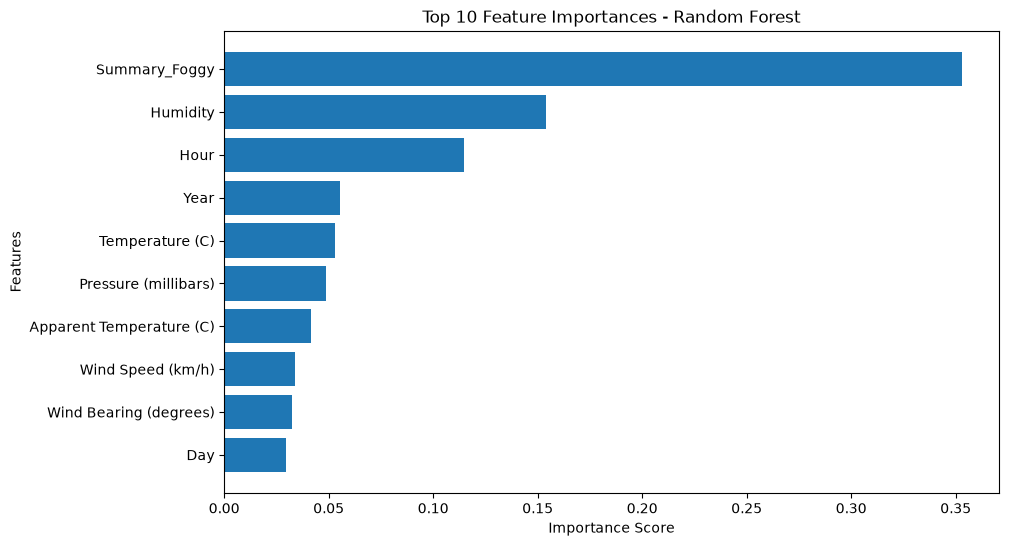

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis() #gca() stands for: Get Current Axes

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Feature Importances - Random Forest")

plt.show()

In [14]:
import joblib

joblib.dump(
    rf_model,
    "../models/random_forest_model.pkl"
)

['../models/random_forest_model.pkl']

In [15]:
import os

os.path.exists("../models/random_forest_model.pkl")

True

# 📌 Notebook 07 Summary - Random Forest Regressor

## Objective

Build a Random Forest Regression model to predict **Visibility (km)** and compare its performance with previous models.

---

## Tasks Completed

- Loaded the feature engineered dataset
- Performed train-test split
- Built a Random Forest Regressor
- Trained the model
- Predicted visibility values
- Evaluated the model using:
  - MAE
  - MSE
  - RMSE
  - R² Score
- Analyzed Feature Importance
- Saved the trained model

---

## Model Performance

| Metric | Value |
|---------|--------|
| MAE | 1.1873 |
| MSE | 3.3982 |
| RMSE | 1.8434 |
| R² Score | 0.8079 |

---

## Model Comparison

| Model | MAE | RMSE | R² Score |
|--------|------|------|----------|
| Linear Regression | 2.4960 | 3.0290 | 0.4813 |
| Decision Tree | 1.5368 | 2.2878 | 0.7041 |
| Random Forest | **1.1873** | **1.8434** | **0.8079** |

The Random Forest Regressor achieved the best performance among the models evaluated so far, demonstrating the strength of ensemble learning for this regression problem.

---

## Output Files

- `models/random_forest_model.pkl`

---

## Next Notebook

➡️ Notebook 08 – XGBoost Regressor